# Two-site DMRG, live

**FYS4480/FYS9480 — week 41, Friday.**

A complete two-site DMRG in about 100 lines of numpy, for the spin-1/2 Heisenberg chain with open ends,

$$\hat H = J\sum_{i=0}^{L-2}\mathbf S_i\cdot\mathbf S_{i+1}, \qquad J = 1 .$$

1. the problem, and exact diagonalisation (ED) as the reference;
2. the algorithm;
3. watching it sweep and optimise two sites at a time;
4. how the bond dimension grows;
5. why capping it costs so little;
6. DMRG against ED.

In [1]:
import time
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import ipywidgets as widgets
from IPython.display import clear_output, display

np.set_printoptions(precision=6, suppress=True, linewidth=120)

# colours of the lecture slides: pink, orange, purple
PINK, ORANGE, PURPLE = '#EB46BD', '#FF6300', '#8331E5'
SLIDES = LinearSegmentedColormap.from_list('slides', [PURPLE, PINK, ORANGE])
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[PINK, ORANGE, PURPLE])
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. The problem, and exact diagonalisation

A chain of $L$ spins has $2^L$ basis states. ED stores the Hamiltonian as a $2^L\times2^L$ matrix
and diagonalises it: exact, but both memory and time grow exponentially with $L$.

In [2]:
# local operators (d = 2), basis (up, down)
d = 2
Id = np.eye(2)
Sz = np.array([[0.5, 0.0], [0.0, -0.5]])
Sp = np.array([[0.0, 1.0], [0.0, 0.0]])          # S^+ |down> = |up>
Sm = Sp.T


def heisenberg_H(L, J=1.0):
    # H = J sum_i S_i . S_{i+1} on an open chain, as a sparse 2^L x 2^L matrix
    h2 = J * (np.kron(Sz, Sz) + 0.5 * (np.kron(Sp, Sm) + np.kron(Sm, Sp)))   # one bond, 4 x 4
    H = sp.csr_matrix((2**L, 2**L))
    for i in range(L - 1):
        H = H + sp.kron(sp.identity(2**i), sp.kron(h2, sp.identity(2**(L - i - 2))), format='csr')
    return H


def ed_full(L):
    # full diagonalisation: every eigenvalue of the dense matrix.  Cost ~ (2^L)^3
    return np.linalg.eigvalsh(heisenberg_H(L).toarray())


def ed_lanczos(L):
    # Lanczos: the ground state only.  Still needs vectors of length 2^L
    return float(spl.eigsh(heisenberg_H(L), k=1, which='SA')[0][0])

In [3]:
print(f'{"L":>3} {"dim = 2^L":>10} {"E0":>14} {"full diag [s]":>14}')
for L in (6, 8, 10, 12):
    t0 = time.time()
    E0 = ed_full(L)[0]
    print(f'{L:3d} {2**L:10d} {E0:14.8f} {time.time() - t0:14.3f}')

  L  dim = 2^L             E0  full diag [s]
  6         64    -2.49357713          0.004
  8        256    -3.37493260          0.007
 10       1024    -4.25803521          0.067
 12       4096    -5.14209063          4.732


Every two extra sites cost a factor $4^3 = 64$ in time. $L = 14$ would take minutes, and
$L = 20$ would need 8 TB just to store the matrix.

## 2. The algorithm

**Matrix product state.** Write the wavefunction as one tensor per site,

$$|\psi\rangle = \sum_{s_0\dots s_{L-1}} A^{s_0}_0 A^{s_1}_1\cdots A^{s_{L-1}}_{L-1}\,|s_0\dots s_{L-1}\rangle ,$$

where $A_i^{s}$ is a $\chi_{i-1}\times\chi_i$ matrix. The **bond dimension** $\chi$ sets how much
entanglement a bond can carry: $\chi = 1$ is a product state, $\chi = 2^{L/2}$ is any state at all.

**One two-site update** (`DMRG.update` below):

1. merge sites $i$ and $i+1$ into one tensor $\boldsymbol\Theta$ of size $\chi\cdot2\cdot2\cdot\chi$;
2. find the lowest eigenvector of the *effective Hamiltonian* for those two sites, with the rest of
   the chain frozen (a small Lanczos problem);
3. split $\boldsymbol\Theta$ back into two sites with an SVD, keeping at most $\chi_{\max}$ singular values
   and recording the discarded weight $\varepsilon_\chi=\sum_{k>\chi}\sigma_k^2$;
4. move one site along.

**One sweep** does this for every bond, left to right and back again.

In [5]:
# ---- the building blocks: the same functions as in code/dmrg_numpy_demo.py ----------------

def heisenberg_mpo(L, J=1.0):
    """W[a, b, s_out, s_in], bond dimension 5, open boundary conditions."""
    D = 5
    W = np.zeros((D, D, d, d))
    W[0, 0] = Id
    W[0, 1] = Sp
    W[0, 2] = Sm
    W[0, 3] = Sz
    W[1, 4] = 0.5 * J * Sm
    W[2, 4] = 0.5 * J * Sp
    W[3, 4] = J * Sz
    W[4, 4] = Id
    return [W.copy() for _ in range(L)]


def env_left(Lenv, A, W):
    """Extend the left environment by one site.  Lenv: (bra, mpo, ket)."""
    X = np.tensordot(Lenv, A, axes=([2], [0]))          # bra, mpo, s, ket'
    X = np.tensordot(X, W, axes=([1, 2], [0, 3]))       # bra, ket', mpo', s_out
    X = np.tensordot(X, A.conj(), axes=([0, 3], [0, 1]))  # ket', mpo', bra'
    return X.transpose(2, 1, 0)


def env_right(Renv, A, W):
    """Extend the right environment by one site."""
    X = np.tensordot(A, Renv, axes=([2], [2]))          # ket_l, s_in, bra_r, mpo_r
    X = np.tensordot(X, W, axes=([1, 3], [3, 1]))       # ket_l, bra_r, mpo_l, s_out
    X = np.tensordot(X, A.conj(), axes=([1, 3], [2, 1]))  # bra, mpo', bra'
    return X.transpose(2, 1, 0)


def apply_Heff(Theta, Lenv, W1, W2, Renv):
    """Matrix-free action of the two-site effective Hamiltonian."""
    X = np.tensordot(Lenv, Theta, axes=([2], [0]))        # bra, mpo, s1, s2, r
    X = np.tensordot(X, W1, axes=([1, 2], [0, 3]))        # bra, s2, r, mpo', s1'
    X = np.tensordot(X, W2, axes=([3, 1], [0, 3]))        # bra, r, s1', mpo'', s2'
    X = np.tensordot(X, Renv, axes=([1, 3], [2, 1]))      # bra, s1', s2', bra_r
    return X


def lanczos(matvec, v0, k=24, tol=1e-12):
    """Lowest eigenpair by Lanczos with full reorthogonalisation."""
    shape = v0.shape
    v = v0.ravel() / np.linalg.norm(v0)
    Q, alpha, beta = [v], [], []
    for j in range(k):
        w = matvec(Q[-1].reshape(shape)).ravel()
        a = float(np.dot(Q[-1], w))
        alpha.append(a)
        w = w - a * Q[-1] - (beta[-1] * Q[-2] if j > 0 else 0.0)
        for q in Q:                                        # reorthogonalise
            w -= np.dot(q, w) * q
        b = np.linalg.norm(w)
        if b < tol or j == k - 1:
            break
        beta.append(b)
        Q.append(w / b)
    T = np.diag(alpha) + np.diag(beta, 1) + np.diag(beta, -1)
    evals, evecs = np.linalg.eigh(T)
    gs = sum(evecs[i, 0] * Q[i] for i in range(len(Q)))
    return evals[0], gs.reshape(shape) / np.linalg.norm(gs)


# ---- the sweep, written so that we can stop after every two-site update -------------------

class DMRG:
    """Two-site DMRG for the open Heisenberg chain.  A[i] has shape (chi_left, d, chi_right)."""

    def __init__(self, L, chi_max, J=1.0):
        self.L, self.chi_max = L, chi_max
        self.W = heisenberg_mpo(L, J)
        self.A = []
        for i in range(L):                          # Neel product state: chi = 1 on every bond
            a = np.zeros((1, d, 1)); a[0, i % 2, 0] = 1.0
            self.A.append(a)
        self.Lenv, self.Renv = [None] * (L + 1), [None] * (L + 1)
        self.Lenv[0] = np.zeros((1, 5, 1)); self.Lenv[0][0, 0, 0] = 1.0
        self.Renv[L] = np.zeros((1, 5, 1)); self.Renv[L][0, 4, 0] = 1.0
        for i in range(L - 1, -1, -1):
            self.Renv[i] = env_right(self.Renv[i + 1], self.A[i], self.W[i])
        self.history, self.n_sweeps = [], 0

    def update(self, i, direction):
        """Optimise sites (i, i+1), split them again, and move one site on."""
        A, W, Lenv, Renv = self.A, self.W, self.Lenv, self.Renv

        # 1. merge the two sites:  Theta[chi_left, s_i, s_i+1, chi_right]
        Theta = np.tensordot(A[i], A[i + 1], axes=([2], [0]))

        # 2. lowest eigenvector of the effective Hamiltonian, with the rest of the chain frozen
        energy, Theta = lanczos(
            lambda T: apply_Heff(T, Lenv[i], W[i], W[i + 1], Renv[i + 2]),
            Theta)

        # 3. SVD, and truncate to chi_max
        chil, _, _, chir = Theta.shape
        U, S, Vt = np.linalg.svd(Theta.reshape(chil * d, d * chir), full_matrices=False)
        keep = min(self.chi_max, np.sum(S > 1e-10))
        eps = float(np.sum(S[keep:] ** 2))              # the discarded weight
        U, S, Vt = U[:, :keep], S[:keep], Vt[:keep]
        S = S / np.linalg.norm(S)

        # 4. the singular values go with the site we move towards; update that environment
        if direction == "right":
            A[i] = U.reshape(chil, d, keep)
            A[i + 1] = (np.diag(S) @ Vt).reshape(keep, d, chir)
            Lenv[i + 1] = env_left(Lenv[i], A[i], W[i])
        else:
            A[i] = (U @ np.diag(S)).reshape(chil, d, keep)
            A[i + 1] = Vt.reshape(keep, d, chir)
            Renv[i + 1] = env_right(Renv[i + 2], A[i + 1], W[i + 1])

        self.history.append(dict(sweep=self.n_sweeps, direction=direction, bond=i, E=energy,
                                 eps=eps, S=S, chis=[a.shape[2] for a in A[:-1]]))
        return energy

    def sweep(self, callback=None):
        """One sweep: left to right, then right to left."""
        for direction in ("right", "left"):
            sites = range(self.L - 1) if direction == "right" else range(self.L - 2, -1, -1)
            for i in sites:
                energy = self.update(i, direction)
                if callback is not None:
                    callback(self)
        self.n_sweeps += 1
        return energy


def dmrg(L, chi_max, n_sweeps=6):
    sim = DMRG(L, chi_max)
    for _ in range(n_sweeps):
        energy = sim.sweep()
    return energy, sim

Check against ED on a chain small enough to diagonalise:

In [6]:
L = 12
E_dmrg, sim = dmrg(L, chi_max=64, n_sweeps=5)
E_ed = ed_lanczos(L)
print(f"DMRG : {E_dmrg:.12f}")
print(f"ED   : {E_ed:.12f}")
print(f"diff : {abs(E_dmrg - E_ed):.1e}")

DMRG : -5.142090632841
ED   : -5.142090632841
diff : 8.9e-15


## 3. Watch it sweep

Red: the two sites being optimised right now. Bars: the bond dimension on every bond.
Bottom: the energy after each two-site update, relative to the exact value from ED. Dotted lines
separate the half sweeps.

The state starts as the Néel product state $|\!\uparrow\downarrow\uparrow\downarrow\dots\rangle$,
so every bond starts at $\chi = 1$.

In [7]:
def draw(sim, k=-1, E_exact=None, n_total=None):
    """One frame: which two sites are being optimised, the bond dimensions, and the energy so far."""
    hist = sim.history
    k = k % len(hist)
    h, L = hist[k], sim.L
    i, sgn = h['bond'], (1 if h['direction'] == 'right' else -1)
    fig, (a0, a1, a2) = plt.subplots(3, 1, figsize=(10, 6.5),
                                     gridspec_kw=dict(height_ratios=[0.45, 1.3, 1.3]))

    # the chain, with the two active sites highlighted
    active = [s in (i, i + 1) for s in range(L)]
    a0.plot(range(L), [0] * L, '-', color='0.6', lw=1.5, zorder=1)
    a0.scatter(range(L), [0] * L, s=[280 if a else 110 for a in active],
               c=[PINK if a else '0.8' for a in active], edgecolor='k', zorder=2)
    a0.annotate('', xy=(i + 0.5 + 0.9 * sgn, 0.75), xytext=(i + 0.5 - 0.9 * sgn, 0.75),
                arrowprops=dict(arrowstyle='->', lw=2.5, color=PINK))
    a0.set(xlim=(-0.7, L - 0.3), ylim=(-0.8, 1.3)); a0.axis('off')
    a0.set_title(f"sweep {h['sweep'] + 1}, moving {h['direction']}:  optimising sites {i} and {i + 1}"
                 f"        E = {h['E']:.8f}", fontsize=12)

    # bond dimension on every bond
    a1.bar(np.arange(L - 1) + 0.5, h['chis'], width=0.6,
           color=[PINK if b == i else PURPLE for b in range(L - 1)])
    a1.axhline(sim.chi_max, ls='--', color='0.6')
    a1.text(L - 0.4, sim.chi_max, r'$\chi_{\max}$', va='bottom', ha='right')
    a1.set(xlim=(-0.7, L - 0.3), ylim=(0, sim.chi_max * 1.18), ylabel=r'bond dimension $\chi$')
    a1.set_xticks(range(L))

    # energy after every two-site update
    E = np.array([x['E'] for x in hist[:k + 1]])
    steps = np.arange(1, k + 2)
    if E_exact is None:
        a2.plot(steps, E, 'o-', ms=3, color=PINK); a2.set_ylabel('E')
    else:
        a2.semilogy(steps, np.maximum(np.abs(E - E_exact), 1e-14), 'o-', ms=3, color=PINK)
        a2.set(ylim=(1e-14, 10), ylabel=r'$E - E_0$')
    n_total = n_total or len(hist)
    for s in range(0, n_total + 1, L - 1):                     # one dotted line per half sweep
        a2.axvline(s + 0.5, color='0.6', ls=':', lw=1)
    a2.set(xlim=(0, n_total + 1), xlabel='two-site update number')
    plt.tight_layout()
    return fig

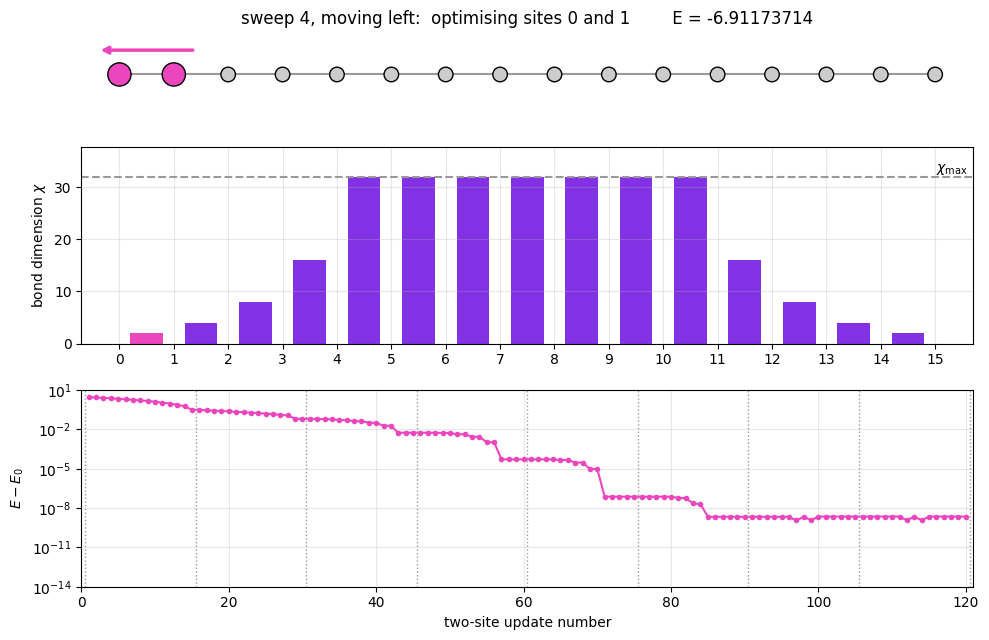

DMRG -6.9117371433   exact -6.9117371456


In [8]:
L, chi_max, n_sweeps = 16, 32, 4          # try: chi_max = 8, or L = 20
E_exact = ed_lanczos(L)

def show(sim):
    clear_output(wait=True)
    fig = draw(sim, E_exact=E_exact, n_total=n_sweeps * 2 * (L - 1))
    display(fig); plt.close(fig)

sim = DMRG(L, chi_max)
for _ in range(n_sweeps):
    sim.sweep(callback=show)
print(f"DMRG {sim.history[-1]['E']:.10f}   exact {E_exact:.10f}")

The same run, step by step (press play, or drag the slider):

In [10]:
def frame(k):
    draw(sim, k, E_exact=E_exact)
    plt.show()

play = widgets.Play(min=0, max=len(sim.history) - 1, interval=250)
slider = widgets.IntSlider(min=0, max=len(sim.history) - 1, description='update',
                           layout=widgets.Layout(width='70%'))
widgets.jslink((play, 'value'), (slider, 'value'))
display(widgets.HBox([play, slider]), widgets.interactive_output(frame, {'k': slider}))

Output()

## 4. How the bond dimension grows

The SVD in step 3 splits a $(\chi_{\rm left}\cdot2)\times(2\cdot\chi_{\rm right})$ matrix, so the new
bond can be up to **twice** as large as its neighbours. Starting from $\chi = 1$, each half sweep
can therefore at most double $\chi$: $1\to2\to4\to8\to\dots$ This is what the two-site update buys;
a one-site update cannot enlarge a bond at all.

With no cap, the growth only stops when the state needs no more (singular values below
$10^{-10}$ are dropped) or the bond is as large as the Hilbert space allows.

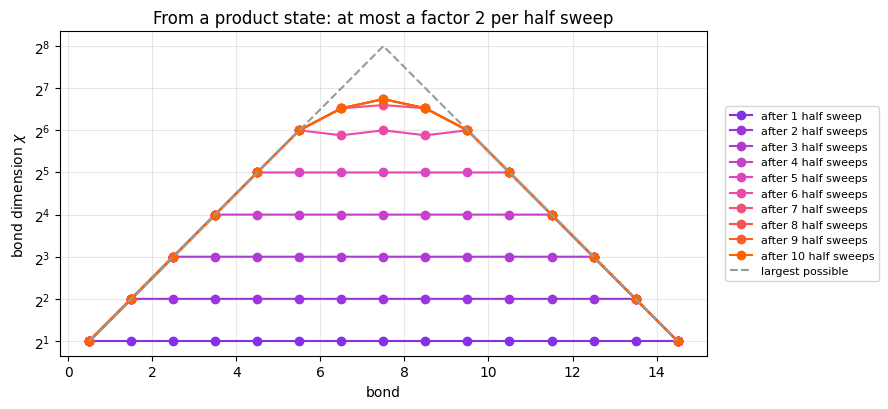

chi at the middle bond after each half sweep: [2, 4, 8, 16, 32, 64, 97, 107, 107, 107]


In [12]:
L = 16                                    # the middle bond can hold at most chi = 2^(L/2) = 256
_, sim_big = dmrg(L, chi_max=10**6, n_sweeps=5)   # no cap at all

fig, ax = plt.subplots(figsize=(9, 4.2))
half = L - 1                              # updates per half sweep
n_half = len(sim_big.history) // half
for n in range(n_half):
    chis = sim_big.history[(n + 1) * half - 1]['chis']
    ax.semilogy(np.arange(L - 1) + 0.5, chis, 'o-', base=2, color=SLIDES(n / (n_half - 1)),
                label=f'after {n + 1} half sweep' + ('s' if n else ''))
bonds = np.arange(1, L)
ax.semilogy(bonds - 0.5, 2.0**np.minimum(bonds, L - bonds), '--', color='0.6', base=2, label='largest possible')
ax.set_xlabel('bond'); ax.set_ylabel(r'bond dimension $\chi$')
ax.set_title('From a product state: at most a factor 2 per half sweep')
ax.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(); plt.show()
print('chi at the middle bond after each half sweep:',
      [sim_big.history[(n + 1) * half - 1]['chis'][L // 2 - 1] for n in range(n_half)])

## 5. Why capping $\chi$ costs so little

The singular values on a bond are the Schmidt coefficients $\sigma_k$ of the cut. In the
ground state of a gapped or critical 1D chain they fall off very fast, so almost all of the weight
sits in the first few. Dropping the rest costs the **discarded weight**
$\varepsilon_\chi = \sum_{k>\chi}\sigma_k^2$ (below: the maximum over bonds in the last sweep).

chi =   2   E - E0 = 3.65e-01   discarded weight = 2.0e-02
chi =   4   E - E0 = 2.78e-02   discarded weight = 1.2e-03
chi =   8   E - E0 = 4.48e-04   discarded weight = 1.9e-05
chi =  16   E - E0 = 4.97e-06   discarded weight = 5.8e-07
chi =  32   E - E0 = 1.47e-08   discarded weight = 9.9e-10
chi =  64   E - E0 = 1.10e-12   discarded weight = 6.7e-14
chi = 128   E - E0 = 5.33e-15   discarded weight = 1.8e-18


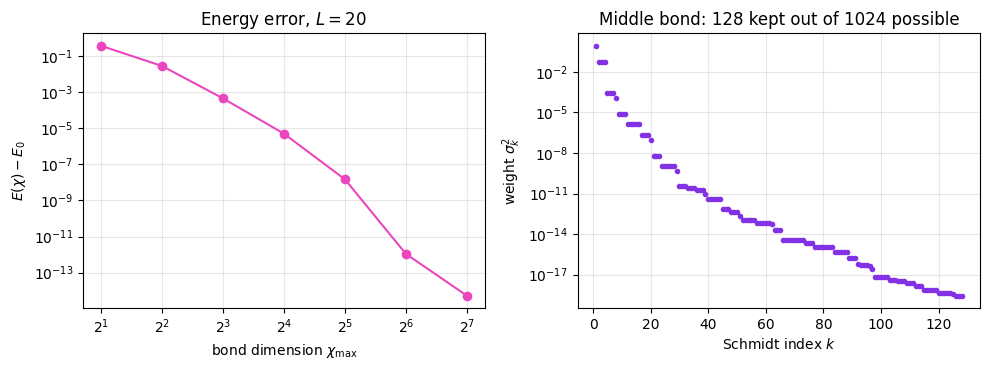

In [13]:
L = 20
E_exact = ed_lanczos(L)
chi_list = [2, 4, 8, 16, 32, 64,128]
err, eps = [], []
for chi in chi_list:
    E, s = dmrg(L, chi, n_sweeps=6)
    err.append(abs(E - E_exact))
    eps.append(max(h['eps'] for h in s.history[-2 * (L - 1):]))
    print(f"chi = {chi:3d}   E - E0 = {err[-1]:.2e}   discarded weight = {eps[-1]:.1e}")

centre = [h for h in s.history if h['bond'] == L // 2 - 1][-1]['S']     # from the chi = 64 run
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].loglog(chi_list, err, 'o-', base=2, color=PINK)
ax[0].set_xlabel(r'bond dimension $\chi_{\max}$'); ax[0].set_ylabel(r'$E(\chi)-E_0$')
ax[0].set_title(f'Energy error, $L={L}$')
ax[0].set_yscale('log', base=10)
ax[1].semilogy(np.arange(1, len(centre) + 1), centre**2, 'o', ms=3, color=PURPLE)
ax[1].set_xlabel('Schmidt index $k$'); ax[1].set_ylabel(r'weight $\sigma_k^2$')
ax[1].set_title(f'Middle bond: {len(centre)} kept out of {2**(L // 2)} possible')
plt.tight_layout(); plt.show()

## 6. DMRG against exact diagonalisation

Same Hamiltonian, same laptop. Dashed lines extrapolate the measured ED times with their known
scaling: $8^L$ for full diagonalisation, $2^L$ per Lanczos iteration.

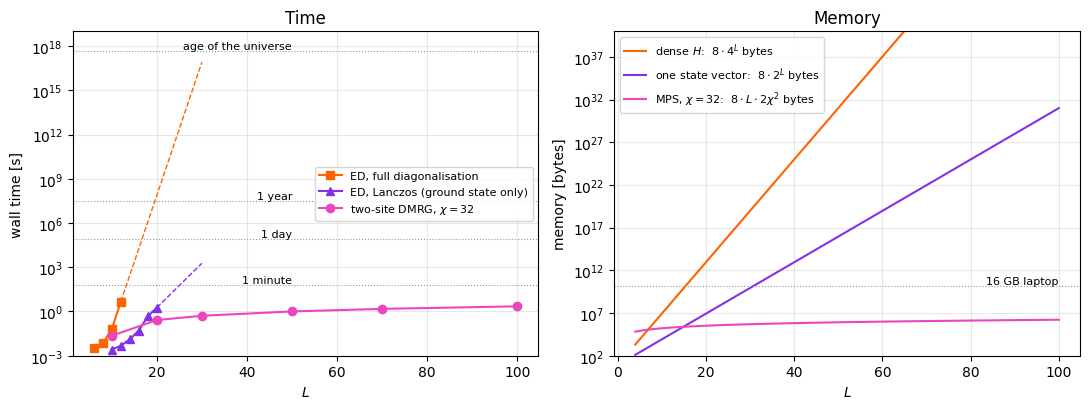

full diagonalisation, L = 12:  4.6 s
Lanczos,              L = 20:  1.8 s
DMRG,                 L = 100: 2.2 s   (Hilbert space dimension 2^100 = 1.3e+30)


In [14]:
def timed(f, *args):
    t0 = time.time(); out = f(*args)
    return time.time() - t0, out

def dmrg_energy(L, chi_max=32, n_sweeps=5):
    return dmrg(L, chi_max, n_sweeps)[0]

L_full, L_lanczos, L_dmrg = [6, 8, 10, 12], [10, 12, 14, 16, 18, 20], [10, 20, 30, 50, 70, 100]
t_full = [timed(ed_full, L)[0] for L in L_full]
t_lanczos = [timed(ed_lanczos, L)[0] for L in L_lanczos]
res_dmrg = [timed(dmrg_energy, L) for L in L_dmrg]
t_dmrg, E_dmrg = [r[0] for r in res_dmrg], [r[1] for r in res_dmrg]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
Lx = np.arange(12, 31)
ax[0].semilogy(L_full, t_full, 's-', color=ORANGE, label='ED, full diagonalisation')
ax[0].semilogy(Lx, t_full[-1] * 8.0**(Lx - 12), '--', color=ORANGE, lw=1)          # cost ~ (2^L)^3
ax[0].semilogy(L_lanczos, t_lanczos, '^-', color=PURPLE, label='ED, Lanczos (ground state only)')
ax[0].semilogy(Lx[8:], t_lanczos[-1] * 2.0**(Lx[8:] - 20), '--', color=PURPLE, lw=1)
ax[0].semilogy(L_dmrg, t_dmrg, 'o-', color=PINK, label=r'two-site DMRG, $\chi = 32$')
for t, lab in [(60, '1 minute'), (86400, '1 day'), (3.15e7, '1 year'), (4.35e17, 'age of the universe')]:
    ax[0].axhline(t, color='0.6', lw=.8, ls=':'); ax[0].text(50, t, lab, ha='right', va='bottom', fontsize=8)
ax[0].set_xlabel('$L$'); ax[0].set_ylabel('wall time [s]'); ax[0].set_ylim(1e-3, 1e19)
ax[0].set_title('Time')
ax[0].legend(fontsize=8, loc='center right')

Lm = np.arange(4, 101)
ax[1].semilogy(Lm, 8.0 * 4.0**Lm, color=ORANGE, label=r'dense $H$:  $8\cdot4^L$ bytes')
ax[1].semilogy(Lm, 8.0 * 2.0**Lm, color=PURPLE, label=r'one state vector:  $8\cdot2^L$ bytes')
ax[1].semilogy(Lm, 8.0 * Lm * 2 * 32**2, color=PINK, label=r'MPS, $\chi=32$:  $8\cdot L\cdot2\chi^2$ bytes')
ax[1].axhline(16e9, color='0.6', lw=.8, ls=':'); ax[1].text(100, 16e9, '16 GB laptop', ha='right', va='bottom', fontsize=8)
ax[1].set_xlabel('$L$'); ax[1].set_ylabel('memory [bytes]'); ax[1].set_ylim(1e2, 1e40)
ax[1].set_title('Memory')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f'full diagonalisation, L = {L_full[-1]}:  {t_full[-1]:.1f} s')
print(f'Lanczos,              L = {L_lanczos[-1]}:  {t_lanczos[-1]:.1f} s')
print(f'DMRG,                 L = {L_dmrg[-1]}: {t_dmrg[-1]:.1f} s   '
      f'(Hilbert space dimension 2^{L_dmrg[-1]} = {2.0**L_dmrg[-1]:.1e})')

No exact result exists to compare the long chains with from ED, but the infinite chain is solved
by the Bethe ansatz: $E/L = 1/4 - \ln 2 \approx -0.44315$.

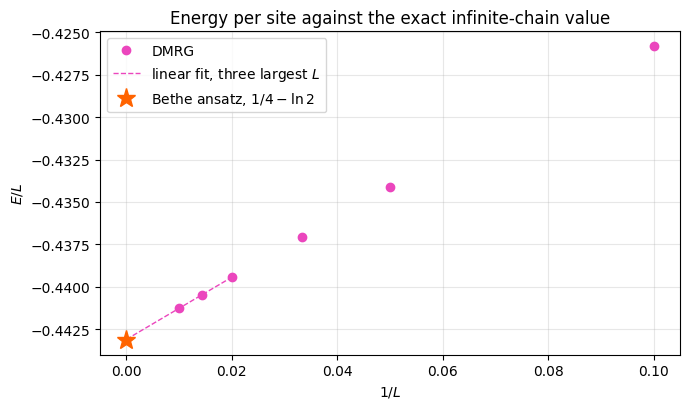

DMRG, extrapolated to 1/L -> 0 : -0.44311
Bethe ansatz                   : -0.44315


In [15]:
e_bethe = 0.25 - np.log(2)                     # exact energy per site of the infinite chain
inv_L, e_site = 1 / np.array(L_dmrg), np.array(E_dmrg) / np.array(L_dmrg)
fit = np.polyfit(inv_L[-3:], e_site[-3:], 1)   # open ends cost an energy ~ 1/L per site

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(inv_L, e_site, 'o', color=PINK, label='DMRG')
ax.plot([0, inv_L[-3]], np.polyval(fit, [0, inv_L[-3]]), '--', color=PINK, lw=1, label='linear fit, three largest $L$')
ax.plot(0, e_bethe, '*', color=ORANGE, ms=14, label=r'Bethe ansatz, $1/4 - \ln 2$')
ax.set_xlabel('$1/L$'); ax.set_ylabel('$E/L$')
ax.set_title('Energy per site against the exact infinite-chain value')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'DMRG, extrapolated to 1/L -> 0 : {fit[1]:.5f}')
print(f'Bethe ansatz                   : {e_bethe:.5f}')

Four digits of the thermodynamic limit, from chains no exact diagonalisation will ever reach,
in a few seconds each.

## Things to try

1. **Starve it.** Set `chi_max = 8` in the animation. The bars hit the ceiling after three half
   sweeps and the energy flattens at an error of order $10^{-4}$: that plateau is set by the
   discarded weight, not by a lack of sweeps.
2. **One sweep is not enough.** Set `n_sweeps = 1`. The bonds have only reached $\chi=4$, and the
   energy is still far off: the bond dimension has to be *grown*, one factor of 2 at a time.
3. **A longer chain.** Set `L = 20` in the animation; the exact reference still takes a couple of
   seconds with Lanczos.
4. **Push ED.** Add `13` to `L_full` in section 6 and wait: it is 8 times slower than $L=12$.
   Then add `200` to `L_dmrg`.
5. **Raise the accuracy.** Change `chi_max=32` to `64` in `dmrg_energy` and compare the
   extrapolated $E/L$ with $1/4-\ln2$ again.